In [19]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import time

# Pfad zu src/ hinzufügen
module_path = Path("..").resolve()
if str(module_path) not in sys.path:
    sys.path.append(str(module_path))

from src.dft import dft, idft, dft_matrix

# 2.1 Diskrete Fouriertransformation (DFT) & Spektralanalyse

#### Die Brücke: Warum wechseln wir vom Reellen (Notebook 1) ins Komplexe (Notebook 2)?


> * **Die Hürde im Reellen (Notebook 1):**  
>   Um eine Schwingung vollständig zu erfassen, reichte eine einzelne reelle Zahl nicht aus. Wir mussten für jede Frequenz **zwei getrennte Basen** ($\cos$ und $\sin$) anlegen und **zwei separate Skalarprodukte (Integrale)** berechnen ($a_k$ und $b_k$).
> 
> * **Die Eleganz im Komplexen ($\mathbb{C}^N$):**  
>   Durch die Eulersche Formel $e^{-i\theta} = \cos(\theta) - i \sin(\theta)$ vereinigt der komplexe Drehzeiger mit dem Drehwinkel $\theta(k, n) = k \cdot n \cdot \frac{2\pi}{N}$ beide Schwingungsformen in sich.  
>   **Ein einziges komplexes Skalarprodukt** projiziert das Signal simultan auf beide Achsen:
>   $$\hat{c}_k = \mathbf{v}_k^T \mathbf{f} = \underbrace{\sum_{n=0}^{N-1} f_n \cos\left(k \cdot n \cdot \frac{2\pi}{N}\right)}_{\mathbf{\text{Re}(\hat{c}_k) = \text{Kosinus-Anteil}}} \; - \; i \cdot \underbrace{\sum_{n=0}^{N-1} f_n \sin\left(k \cdot n \cdot \frac{2\pi}{N}\right)}_{\mathbf{-\text{Im}(\hat{c}_k) = \text{Sinus-Anteil}}}$$
> 
> **Der Gewinn:**  
> Aus zwei getrennten Rechengängen wird **eine einzige lineare Matrixmultiplikation** $\mathbf{\hat{c}} = F_N \cdot \mathbf{f}$:  
> - **Der Betrag $|\hat{c}_k| = \sqrt{\text{Re}^2 + \text{Im}^2}$** liefert direkt die gesuchte Schwingungsstärke (unsere Kontrollwerte $6, \; \sqrt{8}, \; 2, \; \sqrt{8}$).  
> - **Die komplexe Zahl $\hat{c}_k$** hält Realteil (Kosinus) und Imaginärteil (Sinus) fest zusammen, sodass die Rücktransformation (IDFT) das Signal verlustfrei wieder aufbauen kann.

####
---

#### 🔷  1. Was ist ein zeitliches-/ortliches Signal? (Vom kontinuierlichen $f(t)$ zum diskreten Vektor $\mathbf{f}$)
* Ein zeitdiskretes Signal ist ein Zahlenvektor aus $N$ aufeinanderfolgenden Abtastwerten (Samples):
  $$\mathbf{f} = [f_0, f_1, \dots, f_{N-1}]^T \in \mathbb{R}^N \quad (\text{oder } \mathbb{C}^N)$$
* Es ist **keine Treppenfunktion** und **nicht $C^{-1}$**, sondern existiert als Punktmenge rein an den diskreten Zeitindizes $t \in \{0, 1, \dots, N-1\}$.

---

#### 🔷 2. Diskrete Fouriertransformation (DFT) – Analyse (Zeit $\to$ Frequenz)
Die DFT transformiert das Signal vom Zeitbereich in den Frequenzbereich (Basiswechsel):

$$\hat{c}_k = \sum_{n=0}^{N-1} f_n \cdot e^{-i \frac{2\pi}{N} k n}, \quad k = 0, 1, \dots, N-1$$

* **In Matrixform (Lineare Algebra: $\mathbf{c} = P^{-1} \cdot \mathbf{x}$ mit $P^{-1} = F_N$):**
  $$\mathbf{\hat{c}} = F_N \cdot \mathbf{f}$$
  mit der komplexen DFT-Matrix $(F_N)_{k, n} = e^{-i \frac{2\pi}{N} k n}$.
  * Zeilen von $F_N$: Frequenzen $k$ (Schwingungs-Detektoren (für Skalar-Produkt-Projektion)).
  * Spalten von $F_N$: Zeitschritte $t_n$ (gesteuert durch den Zeitindex $n$).

* **Jede einzelne Zeile von $F_N$ repräsentiert eine feste Frequenz $k$ (für die Übersetzung in den Frequenzraum):**
  $$\text{Zeile } k = \begin{pmatrix} 1 & e^{-i \frac{2\pi}{N} k \cdot 1} & e^{-i \frac{2\pi}{N} k \cdot 2} & \dots & e^{-i \frac{2\pi}{N} k \cdot (N-1)} \end{pmatrix}$$
* Multipliziert man die Zeile $k$ mit dem Vektor $\mathbf{f}$, berechnet man das **diskrete Skalarprodukt**:
  $$\hat{c}_k = \langle \text{Zeile } k, \; \mathbf{f} \rangle = \sum_{n=0}^{N-1} f_n \cdot e^{-i \frac{2\pi}{N} k n}$$
* Jede Zeile von $F_N$ wirkt wie ein **spezifischer Frequenz-Detektor (Messer)**, der das Signal mit genau einer Frequenz abtastet und den Betrag dieser Schwingung herausprojiziert.

* **Aufwand:** Matrix $\times$ Vektor $\implies \mathbf{\mathcal{O}(N^2)}$ Multiplikationen.
$$\hat{c}_k = \sum_{n=0}^{N-1} (F_N)_{k, n} \cdot f_n = \underbrace{(F_N)_{k,0} \cdot f_0}_{\text{1. Mult}} + \underbrace{(F_N)_{k,1} \cdot f_1}_{\text{2. Mult}} + \dots + \underbrace{(F_N)_{k,N-1} \cdot f_{N-1}}_{\text{N-te Mult}}$$
  * d.h für $N = 4 \implies 16$  für $N = 1000\implies10^6$, für $N = 1024\implies1.048.576$ Multiplikationen.



---

### 🔷 Das Blattbeispiel $\mathbf{f} = [0, 1, 2, 3]^T \in \mathbb{C}^4$ ($N = 4$)


##### Ausgangslage & mathematischer Rahmen
Wir betrachten das Signal als Vektor im komplexen Vektorraum $\mathbb{C}^4$ über $N = 4$ äquidistante Zeitschritte $t_n$ mit dem Zeitindex $n \in \{0, 1, 2, 3\}$:
- **Grundkreisfrequenz pro Zeitschritt:**
  $$\omega_0 = \frac{2\pi}{N} = \frac{2\pi}{4} = \frac{\pi}{2} = 90^\circ$$
- **Phasenwinkel des Schwingungsarguments:**
  $$\theta(k, n) = \omega_k \cdot t_n = (k \cdot n) \cdot \omega_0 = (k \cdot n) \cdot \frac{\pi}{2}$$
- **Was wollen wir wissen?**  
  *„Aus welchen orthogonalen Schwingungsanteilen (Frequenzen) setzt sich dieses Signal zusammen?“*
- **Wie viele Frequenzen $k$ gibt es?**  
  Genau **$N = 4$ Stück** ($k = 0, 1, 2, 3$), da 4 diskrete Messpunkte im Zeitbereich genau 4 Freiheitsgrade besitzen. Die DFT-Matrix ist deshalb **immer quadratisch ($N \times N$)**, weil die Anzahl der Frequenzen (Zeilen $k$) und die Anzahl der Zeitschritte (Spalten $t_n$) identisch ist.


##### Das Abtast-Prinzip auf dem Einheitskreis (Kontinuierlich vs. Diskret)
* **In Notebook 1 (Reelle Fourier-Reihe):** Die Zeit $t$ lief stetig durch das Intervall, und die Basisfunktionen waren kontinuierliche Schwingungen, über die integriert wurde ($\int f(t) \cos(kt) \, dt$).
* **In Notebook 2 (DFT im $\mathbb{C}^N$):** Der Zeiger läuft nicht stetig, sondern **tastet den Einheitskreis an genau $N$ diskreten Stützpunkten** im mathematisch negativen Drehsinn (im Uhrzeigersinn wegen des negativen Vorzeichens $e^{-i\theta}$) ab.

Die $k$-te **Fourier-Basis** $\mathbf{v}_k$ (Zeile der DFT-Matrix, oft auch Musterschablone genannt) bildet den Zielraum der Transformation:
$$\mathbf{v}_k^H[n] = e^{-i \theta(k, n)} = e^{-i (k \cdot n) \frac{\pi}{2}} = \cos\left(k \cdot n \cdot \frac{\pi}{2}\right) - i \sin\left(k \cdot n \cdot \frac{\pi}{2}\right)$$




#### Schrittweise Herleitung aller 4 Fourier-Basisvektoren $\mathbf{v}_0, \mathbf{v}_1, \mathbf{v}_2, \mathbf{v}_3$



Wir werten nun jeden Basisvektor für alle 4 Zeitschritte (Takte) $n \in \{0, 1, 2, 3\}$ über die Eulersche Formel exakt aus:

> **Basisvektor $\mathbf{v}_0$ (${\color{magenta}{k}} = 0$: Der Gleichanteil / Stillstand)**

Sprungweite (Schrittweite im Frequenzraum) pro Zeitschritt (Takt) $n$: $k \cdot 90^\circ = 0^\circ$ (der Zeiger bleibt auf der reellen Achse bei $+1$ wg. Frequenzindex $k$):
* $n = 0$: $e^{-i \cdot {\color{magenta}{0}} \cdot 0 \cdot \frac{\pi}{2}} = e^0 = \cos(0) - i\sin(0) = \mathbf{1}$
* $n = 1$: $e^{-i \cdot {\color{magenta}{0}} \cdot 1 \cdot \frac{\pi}{2}} = e^0 = \cos(0) - i\sin(0) = \mathbf{1}$
* $n = 2$: $e^{-i \cdot {\color{magenta}{0}} \cdot 2 \cdot \frac{\pi}{2}} = e^0 = \cos(0) - i\sin(0) = \mathbf{1}$
* $n = 3$: $e^{-i \cdot {\color{magenta}{0}} \cdot 3 \cdot \frac{\pi}{2}} = e^0 = \cos(0) - i\sin(0) = \mathbf{1}$

*(Geometrische Bedeutung: Reine Konstante. Multiplikation mit $\mathbf{f}$ bildet die Summe aller Messwerte $\to$ Gleichwert-Offset).*
$$\mathbf{v}_0^T = \begin{pmatrix} 1 & 1 & 1 & 1 \end{pmatrix}$$




> **Basisvektor $\mathbf{v}_1$ ($k = 1$: Erste Harmonische / Grundschwingung (Grundschrittweite im Frequenzraum  = $\omega_{0}$ pro Takt $n$))**

Sprungweite (k-fache Schrittweite im Frequenzraum) pro Zeitschritt (Takt) $n$: $k \cdot 90^\circ = 90^\circ$ im Uhrzeigersinn:
* $n = 0$: $e^{-i \cdot 0} = \cos(0) - i\sin(0) = \mathbf{1}$
* $n = 1$: $e^{-i \frac{\pi}{2}} = \cos(\frac{\pi}{2}) - i\sin(\frac{\pi}{2}) = 0 - i(1) = \mathbf{-i}$
* $n = 2$: $e^{-i \pi} = \cos(\pi) - i\sin(\pi) = -1 - i(0) = \mathbf{-1}$
* $n = 3$: $e^{-i \frac{3\pi}{2}} = \cos(\frac{3\pi}{2}) - i\sin(\frac{3\pi}{2}) = 0 - i(-1) = \mathbf{+i}$

*(Geometrische Bedeutung: eine volle Schwingung/vollen Kreisumlauf ($N \cdot \omega_{0} = 4\cdot\frac{\pi}{2} = 2\pi$) pro volle Periode/über das gesamte 4-Punkte-Messfenster ($T = N = 4$-Takten))*

$$\mathbf{v}_1^T = \begin{pmatrix} 1 & -i & -1 & i \end{pmatrix}$$



> **Basisvektor $\mathbf{v}_2$ ($k = 2$: Nyquist-Frequenz / Höchste Schwingung pro Periode (nach 4-Takten))**

Sprungweite (k-fache Schrittweite im Frequenzraum) pro Zeitschritt (Takt) $n$: $k  \cdot 90^\circ = 180^\circ$ (Halbkreis-Sprünge):
* $n = 0$: $e^{-i \cdot 0} = \mathbf{1}$
* $n = 1$: $e^{-i \pi} = \mathbf{-1}$
* $n = 2$: $e^{-i 2\pi} = \mathbf{1}$
* $n = 3$: $e^{-i 3\pi} = \mathbf{-1}$

*(Geometrische Bedeutung: Genau 2 volle Perioden: Berg $\to$ Tal $\to$ Berg $\to$ Tal. Da der Zeiger ausschließlich auf der reellen Achse zwischen $+1$ und $-1$ springt, ist der Imaginärteil exakt 0!).*

$$\mathbf{v}_2^T = \begin{pmatrix} 1 & -1 & 1 & -1 \end{pmatrix}$$



> **Basisvektor $\mathbf{v}_3$ ($k = 3$: Dritte Harmonische / Spiegelfrequenz)**

Sprungweite (k-fache Schrittweite im Frequenzraum) pro Zeitschritt (Takt) $n$: $k  \cdot 90^\circ = 270^\circ \equiv -90^\circ$ (Dreiviertelkreis vorwärts = Viertelkreis rückwärts):
* $n = 0$: $e^{-i \cdot 0} = \mathbf{1}$
* $n = 1$: $e^{-i \frac{3\pi}{2}} = \mathbf{+i}$
* $n = 2$: $e^{-i 3\pi} = \mathbf{-1}$
* $n = 3$: $e^{-i \frac{9\pi}{2}} = e^{-i \frac{\pi}{2}} = \mathbf{-i}$

*(Geometrische Bedeutung: Komplex konjugiertes Spiegelbild an der reellen Achse (Realteil unverändert und kehrt das Vorzeichen des Imaginärteils um.) zur Grundschwingung: $\mathbf{v}_3 = \overline{\mathbf{v}_1}$).*

$$\mathbf{v}_3^T = \begin{pmatrix} 1 & i & -1 & -i \end{pmatrix}$$



##### Was $k$ physikalisch bedeutet: Volle Kreisumläufe im Zeitfenster
Der Frequenzindex $k$ gibt an, **wie viele vollständige $360^\circ$-Umdrehungen (volle Schwingungen)** der Zeiger über die gesamte Fensterlänge von $N$ Zeitschritten (Takten) vollführt (pro Periode):
$$\text{Gesamtwinkel nach } N \text{ Schritten} = k \cdot \omega_0 \cdot N = k \cdot \frac{2\pi}{N} \cdot N = \mathbf{k \cdot 2\pi} \quad (k \times 360^\circ)$$

| Frequenz $k$ | Sprung pro Schritt $\Delta \theta$ | Gesamtdrehung ($N=4$) | Zeilen-Basis $\mathbf{v}_k^T$ | Physikalische Bedeutung |
| :--- | :--- | :--- | :--- | :--- |
| **$k = 0$** | $0 \cdot \frac{\pi}{2} = \mathbf{0^\circ}$ | $0^\circ$ (Stillstand) | $[1, 1, 1, 1]$ | **Gleichanteil (DC)-Konstante-Achsenabschnitt:** Kein Drehen. Alle Abtastwerte werden addiert ($0+1+2+3=6$). |
| **$k = 1$** | $1 \cdot \frac{\pi}{2} = \mathbf{90^\circ}$ | $\mathbf{1 \times 360^\circ}$ (1 voller Umlauf) | $[1, -i, -1, i]$ | **Grundschwingung (1. Harmonische):** Vollendet genau 1 Zyklus im Fenster. |
| **$k = 2$** | $2 \cdot \frac{\pi}{2} = \mathbf{180^\circ} = \pi$ | $\mathbf{2 \times 360^\circ}$ (2 volle Umläufe) | $[1, -1, 1, -1]$ | **Nyquist-Grenze:** Schnellste Schwingung, es passen 2 volle Schwingungen in eine Periode (Periodendauer halbiert $\frac{T}{2}$ folgt Anzahl volle Schwingungen verdoppelt $+1, -1, +1, -1$). |
| **$k = 3$** | $3 \cdot \frac{\pi}{2} = \mathbf{270^\circ} \equiv -90^\circ$| $\mathbf{3 \times 360^\circ}$ ($1 \times$ rückwärts) | $[1, i, -1, -i]$ | **Spiegelfrequenz (Aliasing):** Drehung um $-90^\circ$, Spiegelbild zu $k = 1$. |

#####
> * **1. Die Kaskade von $N$ (Die fundamentale Stellschraube):**  
>   Die Anzahl der diskreten Messwerte $N$ bestimmt das gesamte System:
>   * Im **Zeitbereich** haben wir $N$ feste Takte ($n = 0, 1, \dots, N-1$).
>   * Im **Frequenzbereich** zerlegt $N$ den Vollkreis ($2\pi$) in elementare Frequenz-Schnitte mit der Grundfrequenz:
>     $$\omega_0 = \frac{2\pi}{N}$$
>     *(Je größer $N$, desto feiner ist der Frequenzschnitt $\omega_0 \to$ höhere spektrale Auflösung!).*
>   * Weil $N$ Zeitpunkte genau $N$ Freiheitsgrade besitzen, gibt es exakt **$N$ orthogonale Frequenzkanäle** ($k = 0, 1, \dots, N-1$).
> 
> * **2. Der Such-Mechanismus für jeden Frequenzkanal $k$:**  
>   Um zu analysieren, wie viel Signalenergie in einen bestimmten Frequenzschnitt $k$ fällt, gehen wir zweistufig vor:
>   1. **Kanal $k$ wird fixiert:** Die Sprungweite (k-fache Schrittweite im Frequenzraum) pro N-Takt auf dem Einheitskreis ist fest (weil $k$ erstmal fest ist): $$\Delta \theta = k \cdot \omega_0 \cdot = k \cdot \frac{2\pi}{N}$$, was steuert noch die fortschreitenden Drehung ?, die N-Takten $n \in \{0, 1, \dots, N-1\} \implies n \cdot \Delta\theta = \theta(k, n) = k \omega_{0} \cdot n$, 
>   2. **Zeit $n$ läuft durch (über N-Takten):** Wir tasten die Schwingung an allen $N$ Takten ab. Die resultierenden $N$ komplexen Zahlen bilden **einen vollständigen Fourier-Basisvektor** $\mathbf{v}_k^T$ (eine Zeile der DFT-Matrix), d.h wir nutzen die Größe des Signals (die N-Takten), um in diesem festen Frequenzschnitt eine Basis für diesen Schnitt zu bestimmen, denn wir sind immer noch in $\mathbb{C}^4$
> 
> * **3. Das Skalarprodukt als Resonanz-Detektor:**  
>   Multiplizieren wir die Zeile $\mathbf{v}_k^T$ mit dem Signalvektor $\mathbf{f}$, wird das Signal über das gesamte Messfenster mit diesem Frequenzmuster verglichen.
>   Das Ergebnis ist **ein einziger komplexer Koeffizient $\hat{c}_k$**:
>   * $\text{Re}(\hat{c}_k)$ und $\text{Im}(\hat{c}_k)$ kodieren simultan die beiden orthogonalen reellen Richtungen (Kosinus und Sinus).
>   * Der Betrag $|\hat{c}_k|$ misst exakt, mit welcher Intensität das Eingangssignal im $k$-ten Frequenzschnitt vertreten ist!




#### Die Fourier-Matrix $F_4$ als Zeilen-Basis

Stapeln wir die 4 abgeleiteten Zeilenvektoren übereinander, entsteht direkt die DFT-Matrix:

$$F_4 = \begin{pmatrix} \mathbf{v}_0^T \\ \mathbf{v}_1^T \\ \mathbf{v}_2^T \\ \mathbf{v}_3^T \end{pmatrix} = \begin{pmatrix}
1 & 1 & 1 & 1 \\
1 & -i & -1 & i \\
1 & -1 & 1 & -1 \\
1 & i & -1 & -i
\end{pmatrix}$$


##### Exakte Berechnung von $\mathbf{\hat{c}} = F_4 \cdot \mathbf{f}$ mit $\mathbf{f} = [0, 1, 2, 3]^T$

Zeile für Zeile multiplizieren (Skalarprodukt der Matrixzeilen mit dem Signalvektor):

* **$k = 0$ (Gleichanteil / Summe):**
  $${\color{cyan}{\hat{c}_0}} = 1(0) + 1(1) + 1(2) + 1(3) = 0 + 1 + 2 + 3 = {\color{cyan}{\mathbf{6}}} \implies |\hat{c}_0| = \mathbf{6}$$

* **$k = 1$ (1. Harmonische / Grundschwingung):**
  $${\color{cyan}{\hat{c}_1}} = 1(0) - i(1) - 1(2) + i(3) = 0 - i - 2 + 3i = {\color{cyan}{\mathbf{-2 + 2i}}} \implies |\hat{c}_1| = \sqrt{(-2)^2 + 2^2} = \mathbf{\sqrt{8}} \approx 2.8284$$

* **$k = 2$ (2. Harmonische / Nyquist-Frequenz):**
  $${\color{cyan}{\hat{c}_2}} = 1(0) - 1(1) + 1(2) - 1(3) = 0 - 1 + 2 - 3 = {\color{cyan}{\mathbf{-2}}} \implies |\hat{c}_2| = \sqrt{(-2)^2 + 0^2} = \mathbf{2}$$

* **$k = 3$ (3. Harmonische / Spiegelfrequenz):**
  $${\color{cyan}{\hat{c}_3}} = 1(0) + i(1) - 1(2) - i(3) = 0 + i - 2 - 3i = {\color{cyan}{\mathbf{-2 - 2i}}} \implies |\hat{c}_3| = \sqrt{(-2)^2 + (-2)^2} = \mathbf{\sqrt{8}} \approx 2.8284$$

>**Ergebnisvektor der Spektralbeträge:**
>$$|\mathbf{\hat{c}}| = [\mathbf{6}, \; \mathbf{\sqrt{8}}, \; \mathbf{2}, \; \mathbf{\sqrt{8}}]^T$$
>*(Exakte Bestätigung der Kontrollwerte aus dem LEA-Aufgabenblatt!)*

---

###

In [14]:
# 1. Definiere Eingangssignal f
f = np.array([0, 1, 2, 3], dtype=float)
N = len(f)

# 2. DFT berechnen: c_hat = F_N @ f
c_hat = dft(f)
magnitudes = np.abs(c_hat) # Beträge der Amplituden (Koeffizienten, die wir brauchen um in den Frequenzraum der Vektor f abbzubilden mit gewechselten Basis (F_N^*))

# 3. Analytische Kontrollwerte aus Blatt
_magnitudes = np.array([6.0, np.sqrt(8), 2.0, np.sqrt(8)])

print("--- SPEKTRALWERTE (KOMPLEX-Koeff) ---")
for k in range(N):
    print(f"c_hat[{k}] = {c_hat[k].real:+.2f} {c_hat[k].imag:+.2f}i | Betrag |c_hat[{k}]| = {magnitudes[k]:.6f}")

print("\n--- KONTROLLVERGLEICH MIT LEA-AUFGABENBLATT ---")
print(f"Numerisch berechnet: {np.round(magnitudes, 6)}")
print(f"Analytisch erwartet: {np.round(_magnitudes, 6)}")
assert np.allclose(magnitudes, _magnitudes), "Fehler: Beträge stimmen nicht überein."
print("-> Verifikation erfolgreich: Beträge stimmen exakt mit [6, sqrt(8), 2, sqrt(8)] überein.")

--- SPEKTRALWERTE (KOMPLEX-Koeff) ---
c_hat[0] = +6.00 +0.00i | Betrag |c_hat[0]| = 6.000000
c_hat[1] = -2.00 +2.00i | Betrag |c_hat[1]| = 2.828427
c_hat[2] = -2.00 -0.00i | Betrag |c_hat[2]| = 2.000000
c_hat[3] = -2.00 -2.00i | Betrag |c_hat[3]| = 2.828427

--- KONTROLLVERGLEICH MIT LEA-AUFGABENBLATT ---
Numerisch berechnet: [6.       2.828427 2.       2.828427]
Analytisch erwartet: [6.       2.828427 2.       2.828427]
-> Verifikation erfolgreich: Beträge stimmen exakt mit [6, sqrt(8), 2, sqrt(8)] überein.


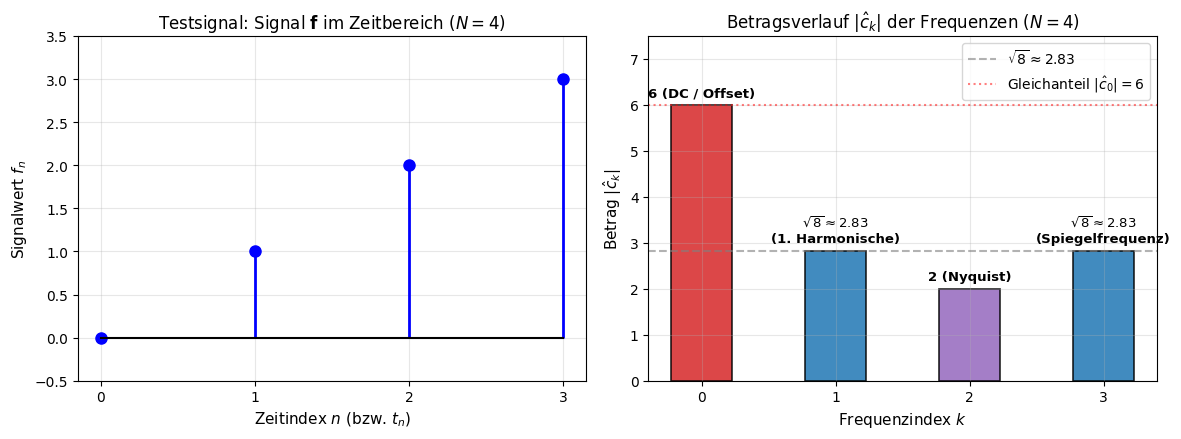

In [15]:
from src.visualization import plot_dft_magnitude_spectrum

# Visualisierung von Zeitbereich f und Betragsspektrum |c_hat| im 1x2-Subplot
plot_dft_magnitude_spectrum(f, c_hat)

>- Die DFT weiß nicht, was vor $n = 0$ oder nach $n = 3$ mit dem Signal geschieht.
> - Weil die Basisfunktionen $e^{-i \omega_k n}$ periodisch sind, **behandelt die DFT das Signal automatisch so, als würde es sich alle $N$ Schritte endlos wiederholen**:
>   $$\dots, \; [0, 1, 2, 3], \; [0, 1, 2, 3], \; [0, 1, 2, 3], \; \dots$$
> - Man nennt dies die **periodische Fortsetzung**. Selbst wenn die 4 Messwerte ein Stück aus einem völlig chaotischen Rauschen oder einer ansteigenden Rampe sind, zerlegt die DFT sie exakt verlustfrei in eine Summe harmonischer Kreisbewegungen, die nahtlos in dieses 4-Punkte-Fenster hineinpassen.

---

### 🔷 3. Inverse Diskrete Fouriertransformation (IDFT) – Synthese (Frequenz $\to$ Zeit)

#### Baut das Signal verlustfrei aus den Spektralwerten im Zeitbereich wieder zusammen:

$$f_t = \frac{1}{N} \sum_{k=0}^{N-1} \hat{c}_k \cdot e^{+i \frac{2\pi}{N} k t}, \quad t = 0, 1, \dots, N-1$$

* **In Matrixform (Lineare Algebra: $\mathbf{x} = P \cdot \mathbf{c}$ mit $P = \frac{1}{N} F_N^*$):**
  $$\mathbf{f} = \frac{1}{N} F_N^* \cdot \mathbf{\hat{c}}$$
  *(Spalten von $F_N$ sind orthogonal $\implies F_N^{-1} = \frac{1}{N} F_N^*$, Vorzeichenumkehr im Exponenten).*

* **Zeilen vs. Spalten:** Vorwärts sind die Frequenzen $k$ die **Zeilen** (Skalarprodukt misst Schwingungsanteil). Durch Transposition $\overline{F_N}^T$ werden sie rückwärts zu den **Spalten** (physikalische Basisschwingungen zum Wiederaufbau).



> 
>**Warum teilt man bei der IDFT durch $N$ (oder unitär durch $\sqrt{N}$)?**
> * Es ist eine reine Konvention, es muss irgendwann exakt einmal durch das **Quadrat der Länge des Basisvektors** geteilt werden.
> * **Quadrierte Vektorlänge:** Jeder diskrete Basisvektor (im Frequenzraum) hat $N$ Einträge $$\mathbf{v}_k = \begin{pmatrix} e^{i \frac{2\pi}{N} k \cdot 0} \\ e^{i \frac{2\pi}{N} k \cdot 1} \\ \vdots \\ e^{i \frac{2\pi}{N} k \cdot (N-1)} \end{pmatrix}$$ mit $|e^{i\dots}| = 1 \implies \|\mathbf{v}_k\|^2 = \sum_{t=0}^{N-1} 1 = \mathbf{N}$
>> **Ergebnis:** Jeder Basisvektor der DFT hat im Computer die quadrierte Länge **$N$** (nicht $1$), d.h die Geometrie im Frequenzraum ist gestreckt und muss normiert werden.
>
> * **Matrix-Produkt:** $F_N^* \cdot F_N = N \cdot I$ es muss $=I$ sein. Ohne Normierung wäre das Signal nach Hin- und Rückweg um das **$N$-fache aufgebläht**.
>
>   1. **Standard-DFT:** Vorwärts $\mathbf{\hat{c}} = F_N \mathbf{f}$, Rückwärts $\mathbf{f} = \frac{1}{N} F_N^* \mathbf{\hat{c}}$. *(Vorteil: Vermeidung von Rundungsfehler (z.B. $\frac{1}{\sqrt{N}}$ in beide Vorwärts- und Rückwärts Normierungskonvention $\sqrt{1000} \approx 31.62277660168...$ eine irrationale Zahl mit unendlich vielen Nachkommastellen)).
>   2. **Unitär / Symmetrisch (Lineare Algebra):** Vor- und rückwärts mit $\mathbf{\frac{1}{\sqrt{N}}}$ skaliert (`norm="ortho"` in Python) $\implies U^* U = I$. Längen und Energien bleiben ohne Korrekturfaktor identisch (Satz von Parseval).
>   3. **Physikalisch (wie in Notebook 1):** Vorwärts geteilt durch $N$, Rückwärts reine Summe (Koeffizienten entsprechen direkt der physikalischen Amplitude).


---


###
---

In [16]:
# 4. Verlustfreie Rekonstruktion mittels IDFT: f_rec = (1/N) * F_N^* @ c_hat
f_reconstructed = idft(c_hat)
rec_error = np.max(np.abs(f - f_reconstructed))

print(f"\nMaximaler IDFT-Rekonstruktionsfehler: {rec_error:.2e}")
print(f"Rekonstruiertes Signal: {np.round(f_reconstructed.real, 4)}")
assert np.allclose(f, f_reconstructed.real), "Fehler bei IDFT (Rekonstruktion)"
print("-> IDFT erfolgreich: Signal verlustfrei auf Maschinengenauigkeit rekonstruiert.")


Maximaler IDFT-Rekonstruktionsfehler: 5.24e-16
Rekonstruiertes Signal: [0. 1. 2. 3.]
-> IDFT erfolgreich: Signal verlustfrei auf Maschinengenauigkeit rekonstruiert.


# 2.2 Warum die FFT die moderne Signalverarbeitung revolutionierte

### 🔷 1. Das „Doppelsummen-Dilemma“ und die naive DFT $\mathcal{O}(N^2)$

#### Die mathematische Struktur (Kontinuierlich vs. Diskret)
Setzt man die Fourier-Analyse (Zerlegung) und die Synthese (Wiederaufbau) direkt ineinander ein, sieht man den zweistufigen Prozess:

* **In der kontinuierlichen Mathematik (Fourier-Doppelintegral):**
  $$f(x) = \frac{1}{2\pi} \int_{-\infty}^{\infty} \underbrace{\left[ \int_{-\infty}^{\infty} f(\xi) \, e^{-i\omega \xi} \, d\xi \right]}_{\mathbf{F(\omega) = \text{Analyse: Skalarprodukt (Frequenz $\omega$ fest, Zeit $\xi$ läuft)}}} \cdot e^{i\omega x} \, d\omega$$
  *(Das äußere Integral $\int \dots d\omega$ ist die Synthese: Es summiert über alle kontinuierlichen Frequenzen $\omega$.)*

* **Im diskreten Computer-Raum $\mathbb{C}^N$ (Verschachtelte Doppelsumme):**
  Setzt man die DFT $\mathbf{\hat{c}} = F_N \mathbf{f}$ in die inverse Transformation $\mathbf{f} = \frac{1}{N} F_N^* \mathbf{\hat{c}}$ ein:
  $$f_n = \frac{1}{N} \sum_{k=0}^{N-1} \underbrace{\left[ \sum_{m=0}^{N-1} f_m \, e^{-i \frac{2\pi}{N} k m} \right]}_{\mathbf{\hat{c}_k = \text{Analyse: Zeile $k \times \mathbf{f}$ (Kanal $k$ fest, Zeittakte $m$ laufen)}}} \cdot e^{+i \frac{2\pi}{N} k n}$$



* **In der Linearen Algebra (Basiswechsel & Spektralzerlegung):**  
  Mit der Transformationsmatrix $P^{-1} = F_N$ (DFT) und der Rücktransformation $P = \frac{1}{N} F_N^*$ (IDFT):
  
  $$\mathbf{f} = \underbrace{\left(\frac{1}{N} F_N^*\right)}_{\text{Rückweg } P \text{ (IDFT)}} \cdot \underbrace{\left( F_N \cdot \mathbf{f} \right)}_{\text{Hinweg } P^{-1} \mathbf{f} \text{ (DFT)}} = \underbrace{\left(\frac{1}{N} F_N^* \cdot F_N\right)}_{\mathbf{= \, I_N \text{ (Einheitsmatrix)}}} \cdot \mathbf{f} = \mathbf{f}$$
  *(Hin- und Rücktransformation heben sich exakt auf: $P \cdot P^{-1} = I_N$.)*

  > 💡 **Der Clou: Eine Frequenz-Manipulation in der Mitte ($P \cdot D \cdot P^{-1}$):**  
  > Schaltet man zwischen Hin- und Rückweg eine diagonale Filter-Matrix $D = \text{diag}(d_0, d_1, \dots, d_{N-1})$ ein (z. B. um Rauschen oder hohe Frequenzen auf $0$ zu setzen), entsteht die klassische Ähnlichkeitstransformation:
  > $$\mathbf{f}_{\text{gefiltert}} = \underbrace{\left(\frac{1}{N} F_N^*\right)}_{\text{Synthese } P} \cdot \underbrace{D}_{\text{Spektralfilter}} \cdot \underbrace{F_N}_{\text{Analyse } P^{-1}} \cdot \mathbf{f}$$
  > Weil die Fourier-Basis lineare Differential- und Faltungs-Operatoren **diagonalisiert**, wird eine extrem teure Faltung im Zeitbereich zu einer simplen, blitzschnellen Multiplikation im Frequenzbereich!

---

#### Woher der quadratische Aufwand $\mathcal{O}(N^2)$ der naiven DFT stammt:
Bei der naiven Berechnung wird diese Struktur stur als zwei ineinander verschachtelte Schleifen ausgeführt:

1. **Innere Summe (1 Frequenzkanal):**  
   Um einen **einzigen** Spektralwert $\hat{c}_k$ zu berechnen, halten wir den Kanal $k$ fest und tasten alle **$N$ Zeitschritte (Takte $m = 0, \dots, N-1$)** ab $\implies \mathbf{N}$ komplexe Multiplikationen.
2. **Äußere Summe (Alle Frequenzkanäle):**  
   Nun lassen wir den Frequenzindex $k$ weiterlaufen und wiederholen diese vollständige $N$-Punkte-Abtastung für **alle $N$ Frequenzkanäle ($k = 0, \dots, N-1$)** von Grund auf neu!
3. **Gesamtaufwand:**
   $$\underbrace{N \text{ Frequenzkanäle } k}_{\text{äußere Schleife (Zeilen)}} \times \underbrace{N \text{ Zeitschritte } m}_{\text{innere Schleife (Spalten)}} = \mathbf{N^2 \text{ komplexe Multiplikationen}}$$

* **Konkreter Vergleich für $N = 1000$ (Aufgabenblatt):**
  * **Naive DFT $\mathcal{O}(N^2)$:**  
    $1000^2 = \mathbf{1.000.000}$ Rechenschritte.
  * **Schnelle FFT (Cooley-Tukey) $\mathcal{O}(N \log_2 N)$:**  
    $1000 \cdot \log_2(1000) \approx 1000 \cdot 10 = \mathbf{10.000}$ Rechenschritte $\implies$ **Faktor 100 schneller!**  
    *(Bei $N = 10^6$ Punkten ist die FFT bereits über **50.000-mal schneller**).*


####

### 🔷 2. Das Divide-&-Conquer-Prinzip der FFT (Cooley-Tukey)
Statt einer teuren $N \times N$ Matrixmultiplikation ($\mathcal{O}(N^2)$) zerlegt die FFT das Signal rekursiv in gerade und ungerade Zeittakte und setzt die Koeffizienten mit Schmetterlings-Operationen (Butterfly) zusammen.

---


#### 1. Der Algorithmus (Pseudocode)

#### 2. Der Rekursionsbaum am Signal $\mathbf{f} = [0, 1, 2, 3]^T$

#### 3. Der Zusammenbau (von unten nach oben):

> Der Index-Halbierungs-Trick der Rekursion:
> Jede Rekursions-Stufe nummeriert ihre eigene Teil-Liste **lokal neu von 0 an**:  
> In der Teil-Liste $[f_0, f_2]$ liegt $f_0$ an **Position 0 (gerade)** und $f_2$ an **Position 1 (ungerade!)**.  
> Was oben ein gerader Messwert war ($n=2$), wird durch die Halbierung unten zur ungeraden Stelle ($2 / 2 = 1$) und bekommt deshalb den Drehfaktor!

* **Stufe 1 (Länge $N = 2$, Schleife nur für $k = 0$ mit $e^{-i \frac{2\pi}{2} \cdot 0} = \mathbf{1}$):**  
  - **Gerader Zweig $[f_0, f_2]$:**  
    $$\hat{c}_{0, \text{gerade}} = \underbrace{f_0}_{\text{Pos 0 (gerade)}} + \; e^0 \cdot \underbrace{f_2}_{\text{Pos 1 (ungerade)}} = 0 + 1 \cdot 2 = \mathbf{2}$$     $$\hat{c}_{1, \text{gerade}} = \underbrace{f_0}_{\text{Pos 0 (gerade)}} - \; e^0 \cdot \underbrace{f_2}_{\text{Pos 1 (ungerade)}} = 0 - 1 \cdot 2 = \mathbf{-2}$$  

  - **Ungerader Zweig $[f_1, f_3]$:**  
    $$\hat{c}_{0, \text{ungerade}} = \underbrace{f_1}_{\text{Pos 0 (gerade)}} + \; e^0 \cdot \underbrace{f_3}_{\text{Pos 1 (ungerade)}} = 1 + 1 \cdot 3 = \mathbf{4}$$    $$\hat{c}_{1, \text{ungerade}} = \underbrace{f_1}_{\text{Pos 0 (gerade)}} - \; e^0 \cdot \underbrace{f_3}_{\text{Pos 1 (ungerade)}} = 1 - 1 \cdot 3 = \mathbf{-2}$$  

* **Stufe 2 (Länge $N = 4$, Gesamtsignal):**  
  Verknüpft die beiden fertigen Teil-Vektoren $\mathbf{\hat{c}}_{\text{gerade}} = [\mathbf{2}, \mathbf{-2}]$ und $\mathbf{\hat{c}}_{\text{ungerade}} = [\mathbf{4}, \mathbf{-2}]$:
  - **Durchlauf $k = 0$ (Drehfaktor $e^{-i \frac{2\pi}{4} \cdot 0} = \mathbf{1}$, befüllt Kanal $0$ und $0 + 2 = \mathbf{2}$):**  
    $$\hat{c}_0 = \hat{c}_{0, \text{gerade}} + e^0 \cdot \hat{c}_{0, \text{ungerade}} = 2 + 1 \cdot 4 = \mathbf{6}$$    $$\hat{c}_2 = \hat{c}_{0, \text{gerade}} - e^0 \cdot \hat{c}_{0, \text{ungerade}} = 2 - 1 \cdot 4 = \mathbf{-2}$$  

  - **Durchlauf $k = 1$ (Drehfaktor $e^{-i \frac{2\pi}{4} \cdot 1} = e^{-i \frac{\pi}{2}} = \mathbf{-i}$, befüllt Kanal $1$ und $1 + 2 = \mathbf{3}$):**  
    $$\hat{c}_1 = \hat{c}_{1, \text{gerade}} + (-i) \cdot \hat{c}_{1, \text{ungerade}} = -2 + (-i) \cdot (-2) = \mathbf{-2 + 2i}$$    $$\hat{c}_3 = \hat{c}_{1, \text{gerade}} - (-i) \cdot \hat{c}_{1, \text{ungerade}} = -2 - (-i) \cdot (-2) = \mathbf{-2 - 2i}$$ 

**Endergebnis:** $\mathbf{\hat{c}} = [\mathbf{6}, \; \mathbf{-2+2i}, \; \mathbf{-2}, \; \mathbf{-2-2i}]^T$

---

#### 4. Laufzeit-Benchmark: DFT vs. FFT ($N = 4$ bis $N = 1024$)

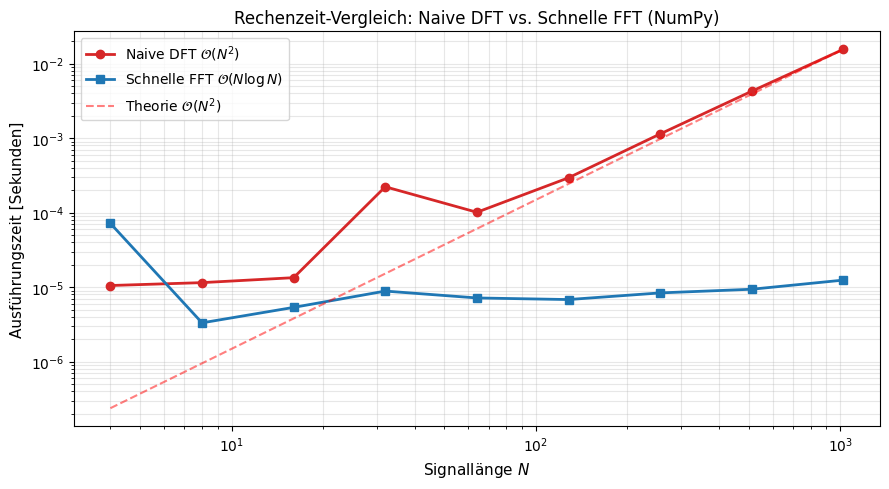

Speedup bei N = 1024: 1252.2x schneller!


In [17]:
# Test-Größen (Zweierpotenzen bis 1024)
N_values = [4, 8, 16, 32, 64, 128, 256, 512, 1024]
times_dft = []
times_fft = []

# Wiederholungen für stabile Zeitmessung
repeats = 10

for N_val in N_values:
    # Zufälliges Testsignal der Länge N
    test_sig = np.random.rand(N_val)
    
    # 1. Zeitmessung naive DFT
    t0 = time.perf_counter()
    for _ in range(repeats):
        _ = dft(test_sig)
    t_dft = (time.perf_counter() - t0) / repeats
    times_dft.append(t_dft)
    
    # 2. Zeitmessung FFT (NumPy / Cooley-Tukey)
    t0 = time.perf_counter()
    for _ in range(repeats):
        _ = np.fft.fft(test_sig)
    t_fft = (time.perf_counter() - t0) / repeats
    times_fft.append(t_fft)

# Plot der Benchmarks im Log-Log-Format
plt.figure(figsize=(9, 5))
plt.loglog(N_values, times_dft, 'o-', color='tab:red', lw=2, ms=6, label=r'Naive DFT $\mathcal{O}(N^2)$')
plt.loglog(N_values, times_fft, 's-', color='tab:blue', lw=2, ms=6, label=r'Schnelle FFT $\mathcal{O}(N \log N)$')

# Asymptotische Hilfslinien
c_dft = times_dft[-1] / (N_values[-1]**2)
plt.loglog(N_values, c_dft * np.array(N_values)**2, 'r--', alpha=0.5, label=r'Theorie $\mathcal{O}(N^2)$')

plt.title('Rechenzeit-Vergleich: Naive DFT vs. Schnelle FFT (NumPy)', fontsize=12)
plt.xlabel('Signallänge $N$', fontsize=11)
plt.ylabel('Ausführungszeit [Sekunden]', fontsize=11)
plt.grid(True, which='both', alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Speedup bei N = 1024: {times_dft[-1] / times_fft[-1]:.1f}x schneller!")

---
#### 5. Numerische Stabilität, Konditionierung & Parseval-Check (Energieerhaltung)


##### 1. Konditionierung der Transformation:
* Die normierte DFT-Matrix $\frac{1}{\sqrt{N}} F_N$ ist **unitär**.
* Alle Singulärwerte sind identisch $\sigma_i = 1 \implies$ **Konditionszahl bezüglich 2-Norm:**
  $$\kappa_2(F_N) = \frac{\sigma_{\max}}{\sigma_{\min}} = \mathbf{1}$$
* Die DFT ist **perfekt konditioniert**: Eingangsrauschen wird nicht verstärkt!

##### 2. Parsevalsche Gleichung (Energieerhaltung):
* Die Gesamtenergie eines Signals ist im Zeitbereich und im Frequenzbereich identisch:
  $$\sum_{t=0}^{N-1} |f_t|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |\hat{c}_k|^2$$
* Für unser Pflichtbeispiel $\mathbf{f} = [0, 1, 2, 3]^T$:
  * **Zeitbereich:** $0^2 + 1^2 + 2^2 + 3^2 = \mathbf{14}$
  * **Frequenzbereich:** $\frac{1}{4} [6^2 + (\sqrt{8})^2 + (-2)^2 + (\sqrt{8})^2] = \frac{1}{4} [36 + 8 + 4 + 8] = \frac{56}{4} = \mathbf{14}$

---

 # 2.3 Praxis-Anwendung – Signal-Entrauschung (Denoising) mit FFT & IFFT

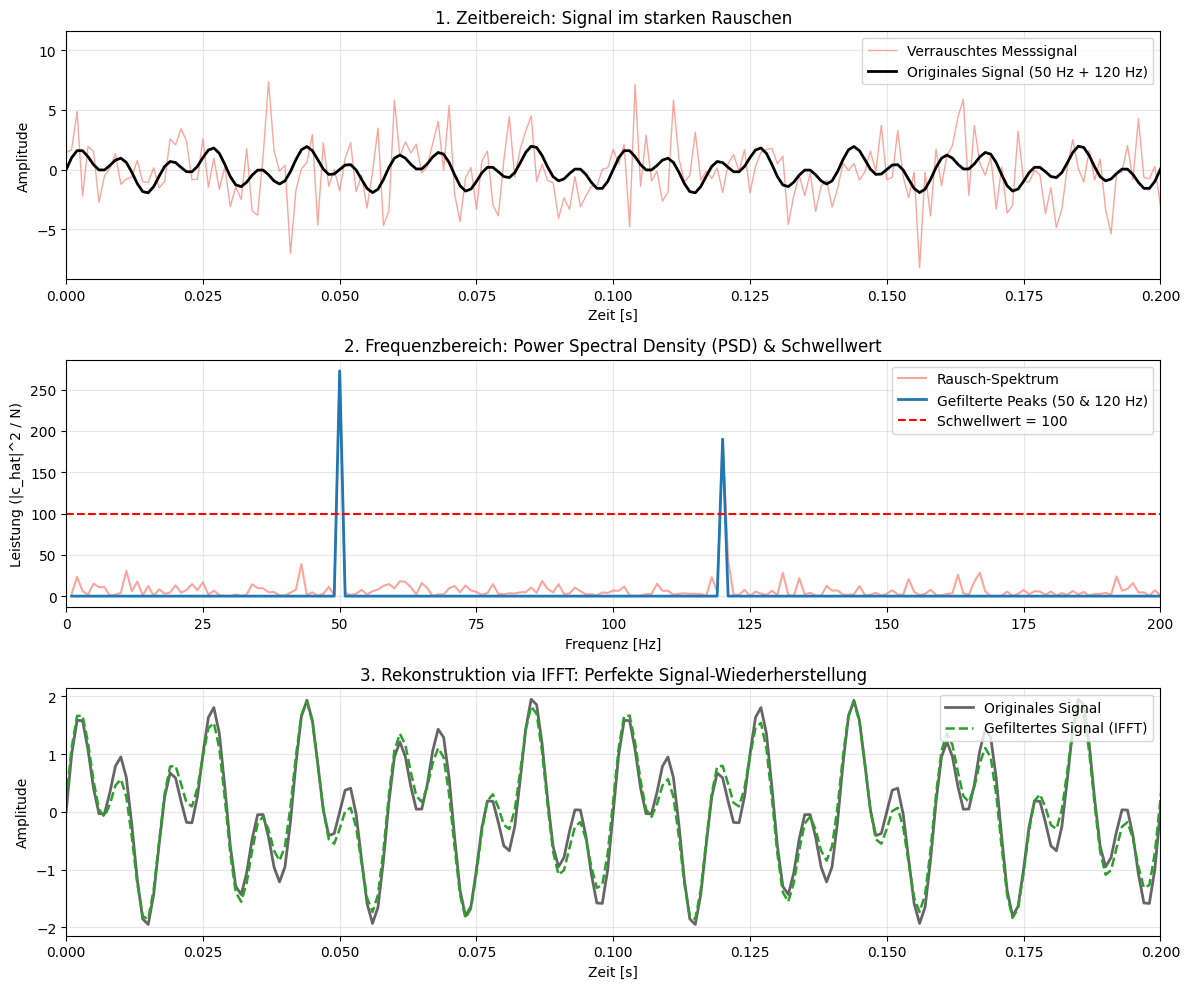

In [18]:
# 
# 1. Synthese des verauchsten Testsignals:
#    - f_original: Zwei reine Sinustöne bei 50 Hz und 120 Hz (Maximalamplitude = 2.0 (2*sin_max_amp = 2))
#    - f_verrauscht: Überlagerung mit weißem Gauß-Rauschen (randn ~ N(0, 1))
#                    mit Rauschamplitude sigma = 2.5. (höher als das eigene Signal - komplett verdeckt) 
#                    Das Rauschen dominiert das Zeitsignal (3-Sigma-Bereich bis +-7.5).
# 
dt = 0.001                                      # Abtastschritt (1 ms)
t = np.arange(0, 1, dt)                          # Zeitachse von 0 bis 1 Sekunde
f_original = np.sin(2 * np.pi * 50 * t) + np.sin(2 * np.pi * 120 * t) # Summe von 2 Frequenzen
f_verrauscht = f_original + 2.5 * np.random.randn(len(t))

# 
# 2. Schnelle Fourier-Transformation (FFT) & Leistungsspektrum (PSD)
# 
N = len(t)                                      # Signallänge N = 1000
c_hat = np.fft.fft(f_verrauscht, N)             # Komplexe Fourier-Koeffizienten c_hat

# PSD = Parseval-Leistung pro Frequenz: |c_hat|^2 / N
leistungsspektrum_PSD = (np.abs(c_hat)**2) / N

frequenzachse = (1 / (dt * N)) * np.arange(N)   # Frequenzachse in Hz
k_positiv = np.arange(1, int(N / 2))           # Nur positive Frequenzen bis Nyquist

# 
# 3. Rausch-Filterung im Frequenzbereich (Hard Thresholding)
# 
schwellwert = 100
signal_maske = leistungsspektrum_PSD > schwellwert  # True nur bei 50 Hz & 120 Hz
c_hat_gefiltert = c_hat * signal_maske              # Rausch-Koeffizienten auf 0 setzen

# 
# 4. Inverse FFT (IFFT): Rücktransformation in den Zeitbereich
# Formel: f_n = (1/N) * sum c_k * e^(+i 2pi/N * k * n)
# 
f_rekonstruiert = np.fft.ifft(c_hat_gefiltert).real

# 
# 5. Visualisierung (3-teiliger Vergleichs-Plot)
# 
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

# Plot 1: Verrauschtes Signal vs. Reines Signal im Zeitbereich
axs[0].plot(t, f_verrauscht, color='salmon', alpha=0.7, lw=1, label='Verrauschtes Messsignal')
axs[0].plot(t, f_original, color='black', lw=2, label='Originales Signal (50 Hz + 120 Hz)')
axs[0].set_title('1. Zeitbereich: Signal im starken Rauschen', fontsize=12)
axs[0].set_xlabel('Zeit [s]', fontsize=10)
axs[0].set_ylabel('Amplitude', fontsize=10)
axs[0].set_xlim(0, 0.2)  # Zoom auf die ersten 0.2 s für gute Sichtbarkeit
axs[0].grid(True, alpha=0.3)
axs[0].legend(loc='upper right', fontsize=10)

# Plot 2: Frequenzbereich (PSD) mit Schwellwert
axs[1].plot(frequenzachse[k_positiv], leistungsspektrum_PSD[k_positiv], color='salmon', alpha=0.7, lw=1.5, label='Rausch-Spektrum')
axs[1].plot(frequenzachse[k_positiv], (leistungsspektrum_PSD * signal_maske)[k_positiv], color='tab:blue', lw=2, label='Gefilterte Peaks (50 & 120 Hz)')
axs[1].axhline(y=schwellwert, color='red', linestyle='--', lw=1.5, label=f'Schwellwert = {schwellwert}')
axs[1].set_title('2. Frequenzbereich: Power Spectral Density (PSD) & Schwellwert', fontsize=12)
axs[1].set_xlabel('Frequenz [Hz]', fontsize=10)
axs[1].set_ylabel('Leistung (|c_hat|^2 / N)', fontsize=10)
axs[1].set_xlim(0, 200)
axs[1].grid(True, alpha=0.3)
axs[1].legend(loc='upper right', fontsize=10)

# Plot 3: Gefiltertes Signal (IFFT) vs. Reines Originalsignal
axs[2].plot(t, f_original, color='black', lw=2, alpha=0.6, label='Originales Signal')
axs[2].plot(t, f_rekonstruiert, color='tab:green', lw=1.8, linestyle='--', label='Gefiltertes Signal (IFFT)')
axs[2].set_title('3. Rekonstruktion via IFFT: Perfekte Signal-Wiederherstellung', fontsize=12)
axs[2].set_xlabel('Zeit [s]', fontsize=10)
axs[2].set_ylabel('Amplitude', fontsize=10)
axs[2].set_xlim(0, 0.2)
axs[2].grid(True, alpha=0.3)
axs[2].legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()